<a href="https://colab.research.google.com/github/shweeta1015/5x5-image-anomaly-detection/blob/main/CNN_Anomaly_Detection_5x5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Creating a 5x5 grayscale image

image = np.array([
    [0, 0, 1, 0, 0],
    [0, 1, 1, 1, 0],
    [1, 1, 1, 1, 1],
    [0, 1, 1, 1, 0],
    [0, 0, 1, 0, 0]
])

print("5x5 Image Matrix:")
print(image)

5x5 Image Matrix:
[[0 0 1 0 0]
 [0 1 1 1 0]
 [1 1 1 1 1]
 [0 1 1 1 0]
 [0 0 1 0 0]]


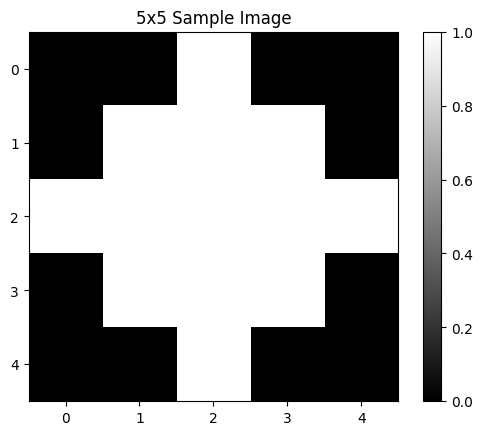

In [ ]:
plt.imshow(image, cmap='gray')
plt.title("5x5 Sample Image")
plt.colorbar()
plt.show()

In [ ]:
# Creating an anomalous 5x5 image

anomaly_image = np.array([
    [0, 0, 1, 0, 0],
    [0, 1, 1, 1, 0],
    [1, 1, 1, 1, 1],
    [0, 1, 1, 1, 0],
    [0, 0, 1, 0, 5]
])

print("Anomalous 5x5 Image:")
print(anomaly_image)

Anomalous 5x5 Image:
[[0 0 1 0 0]
 [0 1 1 1 0]
 [1 1 1 1 1]
 [0 1 1 1 0]
 [0 0 1 0 5]]


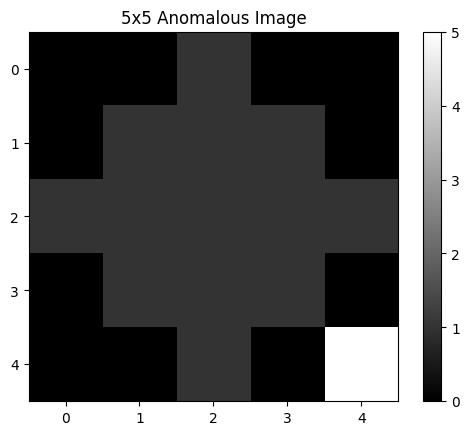

In [ ]:
plt.imshow(anomaly_image, cmap='gray')
plt.title("5x5 Anomalous Image")
plt.colorbar()
plt.show()

In [ ]:
# 3x3 edge detection filter

filter_kernel = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
])

print("CNN Filter:")
print(filter_kernel)

CNN Filter:
[[-1 -1 -1]
 [-1  8 -1]
 [-1 -1 -1]]


In [ ]:
def convolution(image, kernel):

    image_height, image_width = image.shape
    kernel_height, kernel_width = kernel.shape

    output_height = image_height - kernel_height + 1
    output_width = image_width - kernel_width + 1

    output = np.zeros((output_height, output_width))

    for i in range(output_height):
        for j in range(output_width):

            region = image[
                i:i+kernel_height,
                j:j+kernel_width
            ]

            output[i, j] = np.sum(region * kernel)

    return output

In [ ]:
normal_feature_map = convolution(
    image,
    filter_kernel
)

print("Feature Map of Normal Image:")
print(normal_feature_map)

Feature Map of Normal Image:
[[3. 2. 3.]
 [2. 0. 2.]
 [3. 2. 3.]]


In [ ]:
anomaly_feature_map = convolution(
    anomaly_image,
    filter_kernel
)

print("Feature Map of Anomaly Image:")
print(anomaly_feature_map)

Feature Map of Anomaly Image:
[[ 3.  2.  3.]
 [ 2.  0.  2.]
 [ 3.  2. -2.]]


In [ ]:
def relu(x):
    return np.maximum(0, x)

In [ ]:
normal_relu = relu(normal_feature_map)

print("Normal Feature Map after ReLU:")
print(normal_relu)

Normal Feature Map after ReLU:
[[3. 2. 3.]
 [2. 0. 2.]
 [3. 2. 3.]]


In [ ]:
anomaly_relu = relu(anomaly_feature_map)

print("Anomaly Feature Map after ReLU:")
print(anomaly_relu)

Anomaly Feature Map after ReLU:
[[3. 2. 3.]
 [2. 0. 2.]
 [3. 2. 0.]]


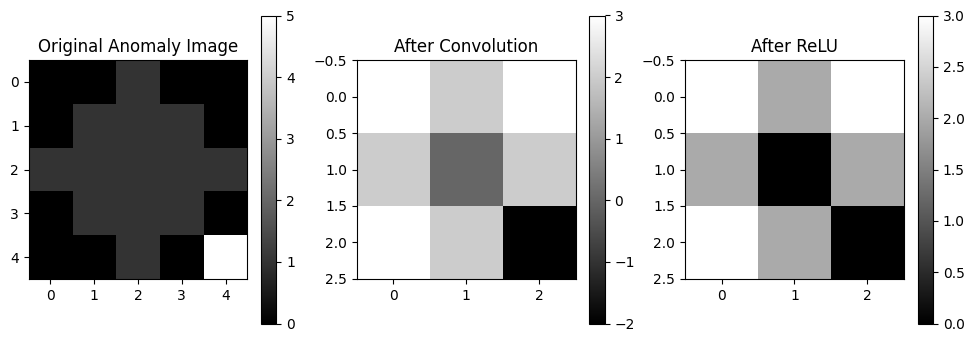

In [ ]:
plt.figure(figsize=(12, 4))

# Original image
plt.subplot(1, 3, 1)
plt.imshow(anomaly_image, cmap='gray')
plt.title("Original Anomaly Image")
plt.colorbar()

# After convolution
plt.subplot(1, 3, 2)
plt.imshow(anomaly_feature_map, cmap='gray')
plt.title("After Convolution")
plt.colorbar()

# After ReLU
plt.subplot(1, 3, 3)
plt.imshow(anomaly_relu, cmap='gray')
plt.title("After ReLU")
plt.colorbar()

plt.show()

In [ ]:
# STEP 17: Create dataset

import numpy as np

np.random.seed(42)

X = []
y = []

# -----------------------------
# Generate NORMAL images
# -----------------------------

for _ in range(1000):

    image = np.zeros((5, 5))

    # Normal pattern
    image[1:4, 1:4] = 1

    # Add small random noise
    image += np.random.normal(0, 0.05, (5, 5))

    X.append(image)
    y.append(0)       # 0 = Normal


# -----------------------------
# Generate ANOMALY images
# -----------------------------

for _ in range(1000):

    image = np.zeros((5, 5))

    # Same normal pattern
    image[1:4, 1:4] = 1

    # Add small random noise
    image += np.random.normal(0, 0.05, (5, 5))

    # Introduce an abnormal pixel
    row = np.random.randint(0, 5)
    col = np.random.randint(0, 5)

    image[row, col] += np.random.uniform(3, 5)

    X.append(image)
    y.append(1)       # 1 = Anomaly


# Convert lists to NumPy arrays
X = np.array(X)
y = np.array(y)

print("Dataset created successfully!")
print("X shape:", X.shape)
print("y shape:", y.shape)

Dataset created successfully!
X shape: (2000, 5, 5)
y shape: (2000,)


In [ ]:
# STEP 18: Check class distribution

unique, counts = np.unique(y, return_counts=True)

for label, count in zip(unique, counts):

    if label == 0:
        print("Normal images :", count)
    else:
        print("Anomaly images:", count)

Normal images : 1000
Anomaly images: 1000


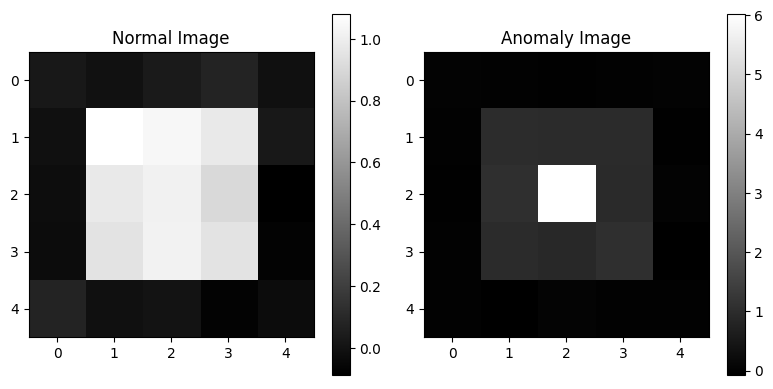

In [ ]:
# STEP 20: Display one normal and one anomaly image

normal_index = np.where(y == 0)[0][0]
anomaly_index = np.where(y == 1)[0][0]

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(X[normal_index], cmap='gray')
plt.title("Normal Image")
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(X[anomaly_index], cmap='gray')
plt.title("Anomaly Image")
plt.colorbar()

plt.tight_layout()
plt.show()

In [ ]:
# STEP 21: Split dataset into training and testing

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

print("Training labels:", y_train.shape)
print("Testing labels :", y_test.shape)

Training data: (1600, 5, 5)
Testing data : (400, 5, 5)
Training labels: (1600,)
Testing labels : (400,)


In [ ]:
# STEP 22: Reshape images for CNN

X_train = X_train.reshape(-1, 5, 5, 1)
X_test = X_test.reshape(-1, 5, 5, 1)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

X_train shape: (1600, 5, 5, 1)
X_test shape : (400, 5, 5, 1)


In [ ]:
# STEP 23: Import TensorFlow

import tensorflow as tf
from tensorflow.keras import layers, models

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0
